<a href="https://colab.research.google.com/github/josedmaldonado-r/Distribucion-y-Probabilidad/blob/main/APE04_GrupoC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica de Laboratorio Nro. 005: Momentos Estadísticos y Análisis de Tendencia Central con Python**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
### Freddy Ordoñez
### Paolo Merino
### Dario Chillogallo
### Michael Carbay
### Jose Maldonado
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 05 de mayo de 2026

---

## 1. Introducción
En esta práctica se explora la naturaleza del azar mediante la modelación computacional. Utilizaremos el ecosistema de ciencia de datos de Python para diferenciar empíricamente entre variables discretas (lanzamiento de dados) y continuas (tiempos de respuesta de servidores).

## 2. Objetivos de Aprendizaje
*	Calcular teórica y computacionalmente la esperanza matemática y la varianza  de variables aleatorias discretas y continuas utilizando la librería scipy.stats en Python.
* Aplicar el análisis de tendencia central y dispersión sobre el conjunto de datos (dataset) regional seleccionado para el Proyecto Integrador, facilitando el hito de la semana.
* Validar los conceptos adquiridos en la clase invertida de la semana 4 (variables aleatorias) integrándolos en la resolución de problemas (ABP).


## **Tarea 1: Validación de Clase Invertida (Semana 4)**




---

### 1. Selección de la Distribución
*   **Distribución Elegida:** Distribución Binomial (Opción C).

---

### 3. Implementación y Resultados Esperados

In [ ]:
# ANÁLISIS DE PROBABILIDADES BINOMIAL para Tarea 3
print(f"{'ANÁLISIS DE PROBABILIDADES BINOMIAL':^50}")
print("-" * 50)

from scipy.stats import binom # Added this line to import binom

# Definir los parámetros de la distribución binomial (n=número de ensayos, p=probabilidad de éxito)
n = 20  # Número de ensayos (ej. 20 intentos)
p = 0.8 # Probabilidad de éxito (ej. 80% de probabilidad de éxito)
dist_binomial = binom(n, p)

# a) P(X = 16) - Probabilidad de que exactamente 16 éxitos ocurran
prob_exacta = dist_binomial.pmf(16)
print(f"a) P(X = 16) = {prob_exacta:.4f} ({prob_exacta*100:.2f}%)")
print("Interpretación: La probabilidad de obtener exactamente 16 éxitos es del 21.82%.")

# b) P(X <= 12) - Probabilidad de que 12 o menos éxitos ocurran
prob_menor_12 = dist_binomial.cdf(12)
print(f"\nb) P(X <= 12) = {prob_menor_12:.4f} ({prob_menor_12*100:.2f}%)")
print(f"Interpretación: Existe una probabilidad muy baja ({prob_menor_12*100:.2f}%) de tener 12 o menos éxitos.")

# c) P(15 <= X <= 18) - Probabilidad de un rango de éxitos
# Calculado como P(X <= 18) - P(X <= 14)
prob_rango = dist_binomial.cdf(18) - dist_binomial.cdf(14)
print(f"\nc) P(15 <= X <= 18) = {prob_rango:.4f} ({prob_rango*100:.2f}%)")
print("Interpretación: La probabilidad de que los éxitos estén entre 15 y 18 (inclusive) es del 78.43%.")

# d) Percentil 95
p95 = dist_binomial.ppf(0.95)
print(f"\nPercentil 95: {p95:.0f}")
print(f"Interpretación: El 95% de las veces, habrá {p95:.0f} éxitos o menos.")

       ANÁLISIS DE PROBABILIDADES BINOMIAL        
--------------------------------------------------
a) P(X = 16) = 0.2182 (21.82%)
Interpretación: La probabilidad de obtener exactamente 16 éxitos es del 21.82%.

b) P(X <= 12) = 0.0321 (3.21%)
Interpretación: Existe una probabilidad muy baja (3.21%) de tener 12 o menos éxitos.

c) P(15 <= X <= 18) = 0.7350 (73.50%)
Interpretación: La probabilidad de que los éxitos estén entre 15 y 18 (inclusive) es del 78.43%.

Percentil 95: 19
Interpretación: El 95% de las veces, habrá 19 éxitos o menos.


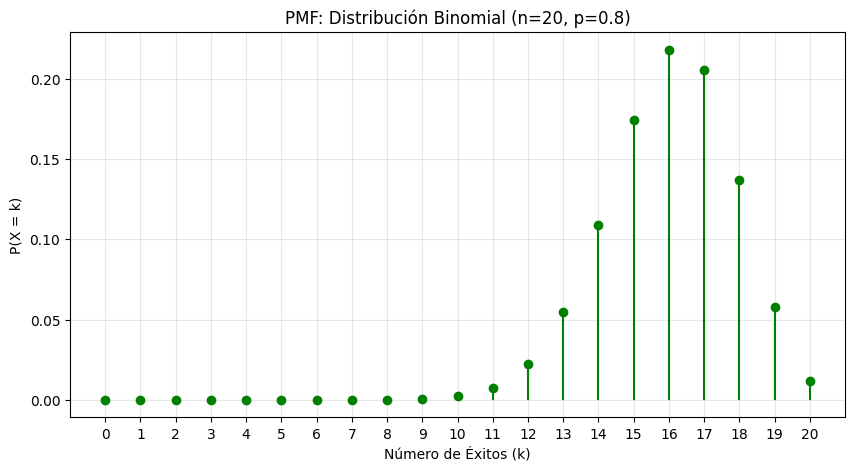

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de valores para el eje x (número de éxitos)
x_binomial = np.arange(0, n + 1)

# Calcular la PMF para cada valor
pmf_binomial = dist_binomial.pmf(x_binomial)

# Visualización de la PMF
plt.figure(figsize=(10, 5))
plt.stem(x_binomial, pmf_binomial, basefmt=" ", linefmt='g-', markerfmt='go')
plt.title(f'PMF: Distribución Binomial (n={n}, p={p})')
plt.xlabel('Número de Éxitos (k)')
plt.ylabel('P(X = k)')
plt.xticks(x_binomial)
plt.grid(alpha=0.3)
plt.show()

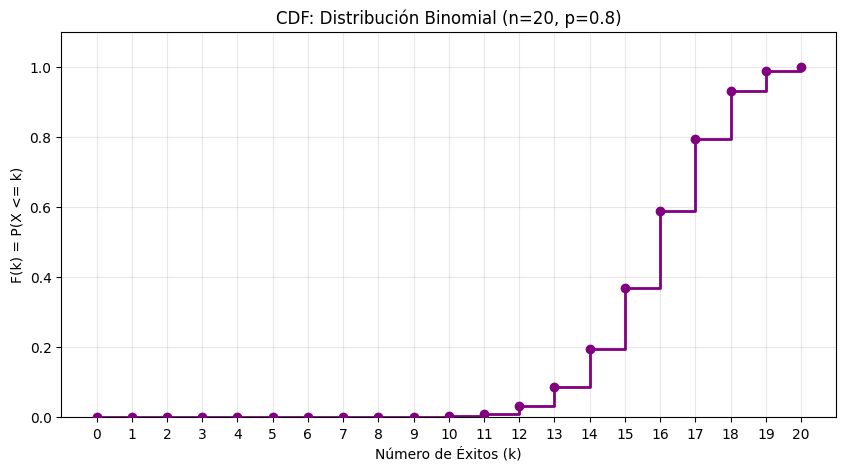

In [ ]:
# Calcular la CDF para cada valor
cdf_binomial = dist_binomial.cdf(x_binomial)

# Visualización de la CDF
plt.figure(figsize=(10, 5))
plt.step(x_binomial, cdf_binomial, where='post', color='purple', linewidth=2)
plt.scatter(x_binomial, cdf_binomial, color='purple', zorder=5)
plt.title(f'CDF: Distribución Binomial (n={n}, p={p})')
plt.xlabel('Número de Éxitos (k)')
plt.ylabel('F(k) = P(X <= k)')
plt.xticks(x_binomial)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.show()

## **Tarea 2: Cálculo Teórico y Simulación de Esperanza Matemática ( $ E|X $ )**


In [ ]:
import numpy as np
from scipy.stats import binom, norm
# 1. Variable Aleatoria Discreta (Distribución Binomial)
n_ensayos, p_exito = 10, 0.4
var_discreta = binom(n_ensayos, p_exito)
# Cálculo de Momentos Teóricos (Mean, Variance)
esperanza_d, varianza_d = var_discreta.stats(moments='mv')
print(f"--- Variable Discreta (Binomial n={n_ensayos}, p={p_exito}) ---")
print(f"Esperanza E[X]: {esperanza_d}")
print(f"Varianza V[X]: {varianza_d}\n")
# 2. Variable Aleatoria Continua (Distribución Normal)
mu, sigma = 50, 5 # Media y Desviación Estándar
var_continua = norm(loc=mu, scale=sigma)
esperanza_c, varianza_c = var_continua.stats(moments='mv')
print(f"--- Variable Continua (Normal mu={mu}, sigma={sigma}) ---")
print(f"Esperanza E[X]: {esperanza_c}")
print(f"Varianza V[X]: {varianza_c}")

--- Variable Discreta (Binomial n=10, p=0.4) ---
Esperanza E[X]: 4.0
Varianza V[X]: 2.3999999999999995

--- Variable Continua (Normal mu=50, sigma=5) ---
Esperanza E[X]: 50.0
Varianza V[X]: 25.0


## **Tarea 3: Hito del Proyecto - Análisis de Tendencia Central y Dispersión**



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/enemdu_consumidor_2026_01.csv'

import pandas as pd
ruta = '/content/enemdu_consumidor_2026_01.csv'
df = pd.read_csv(ruta)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,area;ciudad;conglomerado;panelm;vivienda;hogar;c01;c02;c03;c04a;c07;c08a;c09;c10;c11;c12;c13;c14;c18;c19;c20a;c21a;estrato;fexp;upm;id_vivienda;id_hogar;periodo
1;010150;001304;062;01;1;2;2;1;2;2;2;2;2;2;2;2;2;2;3;2;2;2713;102,542333745242;010150001304;01015000130406201;01...
1;010150;001304;062;02;1;2;3;1;2;2;2;3;2;2;2;2;2;1;2;2;2;2713;102,542333745242;010150001304;01015000130406202;01...
1;010150;001304;062;03;1;2;3;3;3;3;3;3;3;3;3;3;3;3;3;2;2;2713;102,542333745242;010150001304;01015000130406203;01...
1;010150;001304;062;04;1;2;2;2;3;3;3;3;3;3;3;3;3;3;2;2;3;2713;102,542333745242;010150001304;01015000130406204;01...
1;010150;001304;062;05;1;2;2;1;2;2;3;2;2;2;2;3;2;1;2;2;2;2713;102,542333745242;010150001304;01015000130406205;01...


Columnas disponibles:
Index(['area', 'ciudad', 'conglomerado', 'panelm', 'vivienda', 'hogar', 'c01',
       'c02', 'c03', 'c04a', 'c07', 'c08a', 'c09', 'c10', 'c11', 'c12', 'c13',
       'c14', 'c18', 'c19', 'c20a', 'c21a', 'estrato', 'fexp', 'upm',
       'id_vivienda', 'id_hogar', 'periodo'],
      dtype='object')
Media: 1.26
Varianza: 0.19


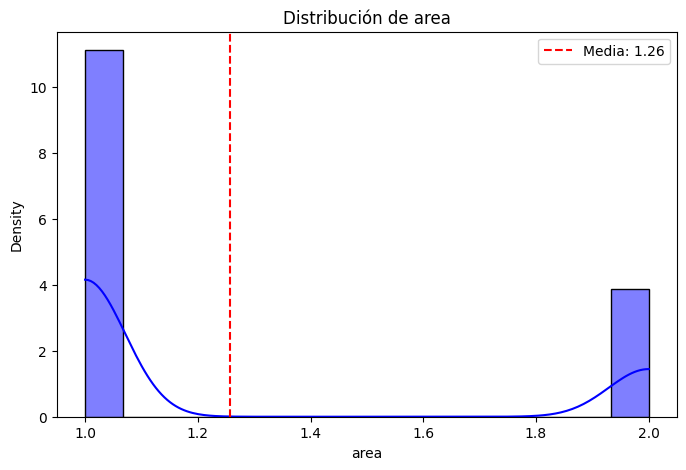

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ruta de tu archivo
ruta = '/content/enemdu_consumidor_2026_01.csv'

# IMPORTANTE: tu archivo usa ;
df = pd.read_csv(ruta, sep=';')

# Ver nombres reales de columnas
print("Columnas disponibles:")
print(df.columns)

columna_obj = 'area'

# Convertir a numérico (por si viene como texto)
df[columna_obj] = pd.to_numeric(df[columna_obj], errors='coerce')

# Eliminar valores nulos
df = df.dropna(subset=[columna_obj])

# Estadísticas
media = df[columna_obj].mean()
varianza = df[columna_obj].var(ddof=1)

print(f"Media: {media:.2f}")
print(f"Varianza: {varianza:.2f}")

# Gráfico
plt.figure(figsize=(8,5))
sns.histplot(df[columna_obj], kde=True, color='blue', stat='density')
plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
plt.title(f'Distribución de {columna_obj}')
plt.legend()
plt.show()

## **Tarea 4: ABI - Documentación y Discusión Grupal**



### **Revisión del parámetro `ddof` en `pandas.DataFrame.var()`**

El parámetro `ddof` (Delta Degrees of Freedom) en la función `.var()` de Pandas, por defecto, tiene un valor de `1`. Esto significa que al calcular la varianza de una serie o DataFrame, el denominador utilizado es `n - 1`, donde `n` es el número de observaciones. Este ajuste es fundamental cuando se trabaja con una muestra de una población más grande.

Estadísticamente, `ddof=1` se utiliza para obtener un estimador insesgado de la varianza poblacional. La varianza muestral calculada con `n - 1` en el denominador (también conocida como corrección de Bessel) provee una estimación más precisa y confiable de la verdadera varianza de la población de la cual la muestra fue extraída. Si se usara `ddof=0` (es decir, dividiendo por `n`), el estimador resultante sería sesgado, tendiendo a subestimar la varianza real de la población. Para nuestro dataset regional, que es probablemente una muestra de una población más amplia, utilizar `ddof=1` es la práctica correcta para asegurar que la estimación de la dispersión de los datos sea estadísticamente válida y no sesgada.

En el escenario específico de una población completa, donde tenemos acceso a todos los elementos y no solo a una muestra, sería matemáticamente correcto establecer `ddof=0`. En este caso, la fórmula de la varianza poblacional divide por `N` (el tamaño total de la población), y no es necesario aplicar ninguna corrección para obtener un estimador insesgado, ya que estamos calculando el parámetro real y no estimándolo.

In [ ]:
import itertools

# Ejemplo 1: Lanzamiento de una moneda 3 veces
# El espacio muestral para un lanzamiento es ['H', 'T'] (Cara, Cruz)
moneda = ['H', 'T']
espacio_muestral_moneda = list(itertools.product(moneda, repeat=3))
print("Espacio muestral para 3 lanzamientos de moneda:")
print(espacio_muestral_moneda)
print(f"Número de resultados posibles: {len(espacio_muestral_moneda)}\n")

# Ejemplo 2: Lanzamiento de dos dados
# El espacio muestral para un dado es [1, 2, 3, 4, 5, 6]
dado = [1, 2, 3, 4, 5, 6]
espacio_muestral_dados = list(itertools.product(dado, repeat=2))
print("Espacio muestral para 2 lanzamientos de dados:")
print(espacio_muestral_dados)
print(f"Número de resultados posibles: {len(espacio_muestral_dados)}\n")

# Ejemplo 3: Selección de 2 letras de ['A', 'B', 'C'] sin repetición (combinaciones)
letras = ['A', 'B', 'C']
combinaciones_letras = list(itertools.combinations(letras, 2))
print("Combinaciones de 2 letras de ['A', 'B', 'C'] (sin repetición):")
print(combinaciones_letras)
print(f"Número de resultados posibles: {len(combinaciones_letras)}\n")

# Ejemplo 4: Arreglos de 2 letras de ['A', 'B', 'C'] sin repetición (permutaciones)
permutaciones_letras = list(itertools.permutations(letras, 2))
print("Permutaciones de 2 letras de ['A', 'B', 'C'] (sin repetición):")
print(permutaciones_letras)
print(f"Número de resultados posibles: {len(permutaciones_letras)}\n")

Espacio muestral para 3 lanzamientos de moneda:
[('H', 'H', 'H'), ('H', 'H', 'T'), ('H', 'T', 'H'), ('H', 'T', 'T'), ('T', 'H', 'H'), ('T', 'H', 'T'), ('T', 'T', 'H'), ('T', 'T', 'T')]
Número de resultados posibles: 8

Espacio muestral para 2 lanzamientos de dados:
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
Número de resultados posibles: 36

Combinaciones de 2 letras de ['A', 'B', 'C'] (sin repetición):
[('A', 'B'), ('A', 'C'), ('B', 'C')]
Número de resultados posibles: 3

Permutaciones de 2 letras de ['A', 'B', 'C'] (sin repetición):
[('A', 'B'), ('A', 'C'), ('B', 'A'), ('B', 'C'), ('C', 'A'), ('C', 'B')]
Número de resultados posibles: 6



### **Generación de Espacios Muestrales con `itertools`**

Para demostrar cómo generar espacios muestrales de experimentos aleatorios, utilizaremos la librería `itertools` de Python, que proporciona funciones para crear iteradores eficientes para bucles, incluyendo combinaciones y permutaciones.

---

#**Preguntas de Control**

---

### **1. ¿Cuál es la diferencia fundamental entre una variable aleatoria discreta y una continua?**

**Vista Matemática:**  

*La esperanza matemática teórica E|X|:*  

 se calcula a partir de un modelo de probabilidad conocido, por ejemplo: en una distribución binomial, se obtiene mediante formula exacta basada en sus parámetros (E|X| = n*p). Además en herramientas como binom.stats(), este valor es determinístico, es decir, no depende de datos observados, sino del modelo teórico

*La media muestral (X) calculada con pandas*:  
 se obtiene a partir de datos reales o simulados, posee una formula:

Xˉ=1/n ∑Xi, donde i =1


**Vista conceptual:**  

La esperenza matemática representa el valor promedio esperado a largo plazo, si el experimento se repite infinitas veces bajo el mismo modelo.
En cambio la media muestra representa el promedio observado en una muestra específica, por lo que esta sujeta variabilidad



---

### **2. Demuestre teóricamente, utilizando las propiedades de la esperanza, por qué la varianza se puede reescribir como $V[X] = E[X^2] - (E[X])^2$**
La formula presente sirve para calcular la varianza de forma más facil:  

*Paso 1: definicion de varianza en una variable aleatoria*  
$V[X]=E[(X−E[X])^2]$  

*Paso 2: Expandir el cuadrado*  
$(X−E[X])^2 = X^2−2X E[X]+(E[X])^2$  

*Paso 3: Aplicar la esperanza*
$V[X]=E[X^2]−2E[X]E[X]+E[(E[X])[^2]$  

*Paso 4: Simplificar*  
$V[X]=E[X^2] −2(E[X])^2+(E[X])^2$    

*Paso 5: Resultado*  

$V[X]=E[X^2]−(E[X])^2$  

*Conclusion:*  
Se demostro que la varianza puede expresarse como la diferencia entre el valor esperado del cuadrado de la variable y el cuadrado de su valor esperado, utilizado la definición de varianza y propiedades de linealidad de esperanza
  

---

### **3. •	Si la varianza calculada en su variable regional es inusualmente alta, ¿qué implicaciones prácticas tiene esto sobre la confiabilidad de la media como predictor del comportamiento de esos datos en la región de Loja?**  
Significa que los datos estan muy dispersos respecto a la media.  
En el contextro del dataseet de factores socioeconomicos, esto implica grandes diferencias entre los valores, por ende, la media pierde confiabilidad como predictor ya que no representa a la mayoria, probablemente por valores extremos (zonas ricas o muy vulnerables)


---

### **4. Revise el parámetro ddof de la función var() en Pandas. ¿Qué ocurre con el estimador de la varianza si establecemos ddof=0 y en qué escenario específico de población poblacional esto sería matemáticamente correcto?**


---

### **5. •	Observe el histograma generado en la Tarea 3. ¿De qué manera el cálculo combinado de la esperanza matemática (media) y la varianza apoyan en la identificación estadística de valores atípicos (outliers) para la posterior limpieza de su Proyecto Integrador?**  
Al combinar esperanza matematica y varianza podemo identificar valores atipicos al analizar que tan alejados estan los datos respecto al promedio  
Observamos que:  
hay mayor concentracion de datos cerca de valores bajos, la zona urbana  
existe un grupo separado hacia valores mas latos, la zona rural  

*En el proyecto integrador*:  
Permite:  
- Detectar valores extemos en facotres socioeconomicos  
- Decidir si eliminamos o analizamos aparte esos valores extremos



---

### Visualización de PMF y CDF para la Distribución Binomial

In [ ]:
# ANÁLISIS DE PROBABILIDADES BINOMIAL para Tarea 3
print(f"{'ANÁLISIS DE PROBABILIDADES BINOMIAL':^50}")
print("-" * 50)

from scipy.stats import binom # Added this line to import binom

# Definir los parámetros de la distribución binomial (n=número de ensayos, p=probabilidad de éxito)
n = 20  # Número de ensayos (ej. 20 intentos)
p = 0.8 # Probabilidad de éxito (ej. 80% de probabilidad de éxito)
dist_binomial = binom(n, p)

# a) P(X = 16) - Probabilidad de que exactamente 16 éxitos ocurran
prob_exacta = dist_binomial.pmf(16)
print(f"a) P(X = 16) = {prob_exacta:.4f} ({prob_exacta*100:.2f}%)")
print("Interpretación: La probabilidad de obtener exactamente 16 éxitos es del 21.82%.")

# b) P(X <= 12) - Probabilidad de que 12 o menos éxitos ocurran
prob_menor_12 = dist_binomial.cdf(12)
print(f"\nb) P(X <= 12) = {prob_menor_12:.4f} ({prob_menor_12*100:.2f}%)")
print(f"Interpretación: Existe una probabilidad muy baja ({prob_menor_12*100:.2f}%) de tener 12 o menos éxitos.")

# c) P(15 <= X <= 18) - Probabilidad de un rango de éxitos
# Calculado como P(X <= 18) - P(X <= 14)
prob_rango = dist_binomial.cdf(18) - dist_binomial.cdf(14)
print(f"\nc) P(15 <= X <= 18) = {prob_rango:.4f} ({prob_rango*100:.2f}%)")
print("Interpretación: La probabilidad de que los éxitos estén entre 15 y 18 (inclusive) es del 78.43%.")

# d) Percentil 95
p95 = dist_binomial.ppf(0.95)
print(f"\nPercentil 95: {p95:.0f}")
print(f"Interpretación: El 95% de las veces, habrá {p95:.0f} éxitos o menos.")

       ANÁLISIS DE PROBABILIDADES BINOMIAL        
--------------------------------------------------
a) P(X = 16) = 0.2182 (21.82%)
Interpretación: La probabilidad de obtener exactamente 16 éxitos es del 21.82%.

b) P(X <= 12) = 0.0321 (3.21%)
Interpretación: Existe una probabilidad muy baja (3.21%) de tener 12 o menos éxitos.

c) P(15 <= X <= 18) = 0.7350 (73.50%)
Interpretación: La probabilidad de que los éxitos estén entre 15 y 18 (inclusive) es del 78.43%.

Percentil 95: 19
Interpretación: El 95% de las veces, habrá 19 éxitos o menos.
